In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.shape

(211224, 16)

In [6]:
sentiment.shape

(2644, 4)

In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
trades = trades.drop_duplicates()

In [10]:
sentiment = sentiment.drop_duplicates()

In [11]:
trades = trades.dropna()

In [12]:
sentiment = sentiment.dropna()

In [18]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [43]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'] , errors ='coerce')
trades['date'] = trades['Timestamp IST'].dt.date

In [46]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [48]:
trades = trades.dropna(subset=['date'])

In [53]:
df = trades.merge(sentiment, on='date', how='left')

In [54]:
df['classification'].value_counts()

,count
classification,
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


In [58]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

In [64]:
# Profit
df['Closed PnL'].describe()

,Closed PnL
count,79225.000000
mean,71.681477
std,1243.590869
min,-117990.104100
25%,0.000000
50%,0.000000
75%,9.008356
max,135329.090100


In [67]:
# Win/Loss
df['win'] = df['Closed PnL'] > 0

In [68]:
# Trade Count
df.groupby('date').size()

,0
date,
2023-01-05,3
2023-05-12,9
2024-01-01,18
2024-01-02,6
2024-01-03,137
...,...
2025-11-04,1096
2025-12-01,602
2025-12-02,1031


In [59]:
# Pnl vs Sentiment
df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,1.891632
Extreme Greed,205.816345
Fear,128.287950
Greed,53.988003
Neutral,27.088803


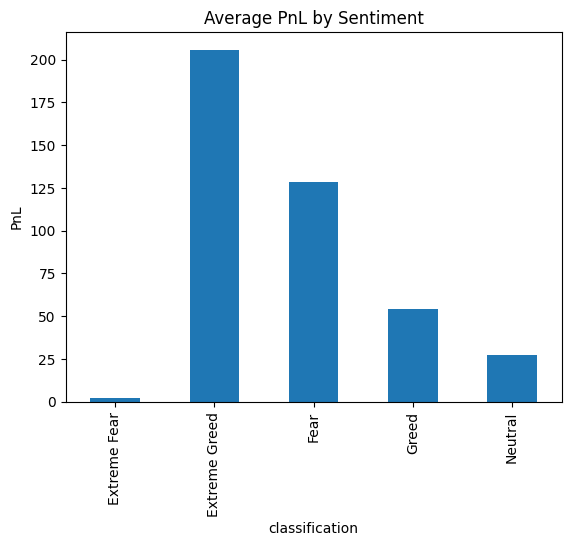

In [73]:
import matplotlib.pyplot as plt

# PnL vs Sentiment
df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average PnL by Sentiment')
plt.ylabel('PnL')
plt.show()

In [61]:
# Win Rate
df['win'] = df['Closed PnL'] > 0
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.292777
Extreme Greed,0.553282
Fear,0.381787
Greed,0.435707
Neutral,0.494920


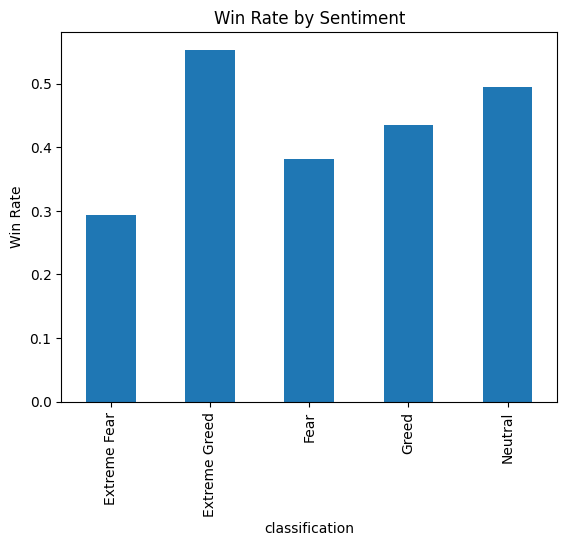

In [74]:
# Win rate vs Sentiment
df.groupby('classification')['win'].mean().plot(kind='bar')
plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate')
plt.show()

In [62]:
# Trade size
df.groupby("classification")['Size USD'].mean()

,Size USD
classification,
Extreme Fear,4118.761840
Extreme Greed,3242.085086
Fear,5744.782685
Greed,5051.878829
Neutral,4332.202906


In [63]:
# Trade Count
df.groupby('classification').size()

,0
classification,
Extreme Fear,2326
Extreme Greed,5621
Fear,13869
Greed,11292
Neutral,2756


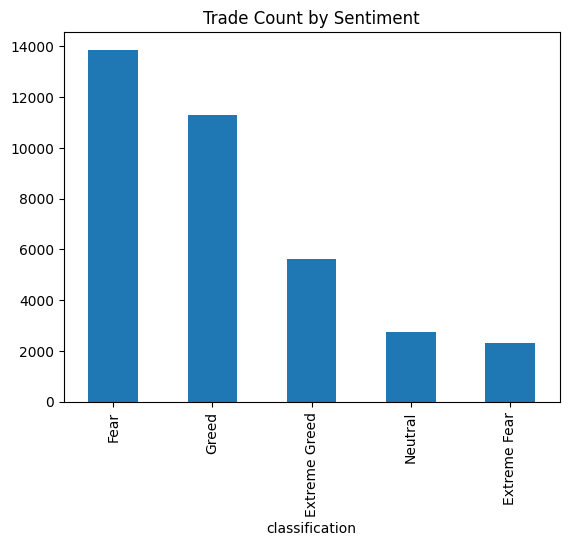

In [72]:
# Trade count
df['classification'].value_counts().plot(kind='bar')
plt.title('Trade Count by Sentiment')
plt.show()

## Actionable Trading Strategies

### Strategy 1: Trade Aggressively in Bullish Sentiment (Greed)
- During Extreme Greed periods, traders show higher profitability and win rates
- Traders can increase participation during these periods
- However, risk control should still be maintained due to volatility

### Strategy 2: Be Cautious During Fear Periods
- Fear and Extreme Fear periods show lower profitability
- Trade sizes tend to increase, indicating risky behavior
- Traders should reduce position sizes and avoid overtrading during these conditions

## Final Insights

- Traders perform best during Extreme Greed conditions, showing highest average PnL
- Extreme Fear conditions result in lowest profitability
- Win rate is highest during bullish sentiment (Extreme Greed)
- Trade sizes increase during Fear, indicating panic or aggressive trading
- Neutral sentiment shows moderate and stable performance

### Overall Conclusion:
Market sentiment has a clear impact on trading performance, with bullish sentiment leading to better outcomes.